# tDCBAM - Triplet-DenseNet121-CBAM | BhSig-Hindi Dataset

## Step 1 — Imports & Reproducibility

In [1]:
import os, sys, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
import seaborn as sns

REPO_ROOT = os.path.abspath(os.path.join(os.path.abspath(os.getcwd()), '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from models.Triplet_Siamese_Similarity_Network import tDCBAM
from losses.triplet_loss                       import TripletLoss
from utils.model_evaluation                    import (compute_metrics, _plot_det_curve,
                                                        _plot_far_frr, _plot_confusion_matrix,
                                                        _plot_score_distribution, _plot_roc_curve)
from dataloader.tDCBAM_trainloader import get_transforms, sample_augment_params, preprocess_image


def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" > [Seed] {seed}")


seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [Device] {DEVICE}" +
      (f"  ({torch.cuda.get_device_name()})" if torch.cuda.is_available() else ""))

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [Seed] 42
 > [Device] cuda  (NVIDIA GeForce RTX 5080)


## Step 2 - Configuration

In [2]:
DATASET = 'bhsig_hindi'

_CONFIG_PATH = os.path.join(REPO_ROOT, 'config', 'configs.json')
if not os.path.exists(_CONFIG_PATH):
    raise FileNotFoundError(
        f"configs.json not found at {_CONFIG_PATH}. "
        "Expected location: <REPO_ROOT>/config/configs.json"
    )

with open(_CONFIG_PATH) as _f:
    _ALL_CONFIGS = json.load(_f)

if DATASET not in _ALL_CONFIGS:
    raise KeyError(
        f"Dataset key '{DATASET}' not found in configs.json. "
        f"Available keys: {list(_ALL_CONFIGS.keys())}"
    )

_CFG = _ALL_CONFIGS[DATASET]

DATASET_NAME  = _CFG['dataset_name']
NOTEBOOK_NAME = f'tDCBAM_{DATASET}'

SPLIT_DIR      = os.path.join(REPO_ROOT, 'data',        'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'proposed_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals',  NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,       exist_ok=True)

SPLIT_RATIOS = ['70_15_15', '65_18_18', '60_20_20']
IMG_SIZE     = 224
INPUT_SHAPE  = (IMG_SIZE, IMG_SIZE)
NUM_WORKERS  = 4
FEATURE_DIM  = 1024

TRAIN_EPOCHS          = _CFG['epochs']
TRAIN_PHASE1_EPOCHS   = _CFG['phase1_epochs']
TRAIN_LR              = _CFG['lr']
TRAIN_MARGIN          = _CFG['margin']
TRAIN_WEIGHT_DECAY    = _CFG['weight_decay']
TRAIN_BATCH_SIZE      = _CFG['batch_size']
BACKBONE_LR_RATIO     = _CFG['backbone_lr_ratio']
HARD_NEG_RATIO        = _CFG['hard_neg_ratio']
SCHEDULER_PATIENCE    = _CFG['scheduler_patience']
# Number of consecutive Phase 2 validation checks with active triplet fraction
# below 1% before training is stopped early. Zero active triplets means the
# margin constraint is satisfied everywhere — no gradient signal remains.
# Each check covers VAL_EVERY=3 epochs, so patience=5 → 15 epochs of silence.
ZERO_ACTIVE_PATIENCE  = _CFG.get('zero_active_patience', 5)

print(f" > [Config] Loaded from: {_CONFIG_PATH}")
print(f" > [Config] Dataset: {DATASET_NAME} (key: '{DATASET}')")
print(f" > [Config] Epochs: {TRAIN_EPOCHS} (P1 frozen: {TRAIN_PHASE1_EPOCHS})")
print(f" > [Config] LR: {TRAIN_LR} | Margin: {TRAIN_MARGIN} | "
      f"WD: {TRAIN_WEIGHT_DECAY} | Batch: {TRAIN_BATCH_SIZE}")
print(f" > [Config] Backbone LR ratio: {BACKBONE_LR_RATIO} | "
      f"Hard neg ratio: {HARD_NEG_RATIO} | "
      f"Scheduler patience: {SCHEDULER_PATIENCE}")
print(f" > [Config] Zero active patience: {ZERO_ACTIVE_PATIENCE} val checks "
      f"(~{ZERO_ACTIVE_PATIENCE * 3} epochs)")


 > [Config] Loaded from: /home/lawrence/workspace/thesis/thesis/config/configs.json
 > [Config] Dataset: BHSig-Hindi (key: 'bhsig_hindi')
 > [Config] Epochs: 100 (P1 frozen: 13)
 > [Config] LR: 0.0003631126919850215 | Margin: 0.5538629628394433 | WD: 0.0008250424348545071 | Batch: 32
 > [Config] Backbone LR ratio: 0.08894603873252609 | Hard neg ratio: 0.5026988564275506 | Scheduler patience: 3
 > [Config] Zero active patience: 5 val checks (~15 epochs)


## Step 3 — Transforms

In [3]:
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)

print(" > [Transforms] train_transform: augmentation ON  (geometric)")
print(" > [Transforms] val_transform  : augmentation OFF (preprocessing only)")

 > [Transforms] train_transform: augmentation ON  (geometric)
 > [Transforms] val_transform  : augmentation OFF (preprocessing only)


## Step 4 — Datasets

In [4]:
class SplitTripletDataset(Dataset):
    """
    Triplet dataset for triplet-loss training.

    Generates (Anchor, Positive, Negative) triplets with offline hard
    negative mining:
        hard_neg_ratio  of negatives are skilled forgeries from the
                        same writer (hard negatives).
        1-hard_neg_ratio of negatives are genuine signatures from a
                        randomly chosen other writer (easy negatives).

    Triplets are regenerated each epoch via _generate_triplets() to prevent
    the model from memorising fixed pairings across epochs.

    Augmentation strategy (training=True):
        Flip    : Sampled ONCE per triplet, shared across anchor, positive,
                  and negative. Ensures orientation is consistent within
                  a triplet — inconsistent flip would corrupt the loss signal
                  by introducing directional mismatch as a training artifact.

        Rotation, zoom, jitter : Sampled INDEPENDENTLY per image. Forces the
                  model to learn stroke-level similarity invariant to scale,
                  rotation, and position variation. This is the primary
                  mechanism for learning spatial invariance.

    Augmentation strategy (training=False):f
        val_transform is applied per-image (no augmentation).

    Args:
        user_dict      (dict)    : {uid: {'genuine': [...], 'forged': [...]}}
        input_shape    (tuple)   : Canvas size. Default (224, 224).
        val_transform  (callable): Transform for val/test. No augmentation.
        training       (bool)    : True for train split, False for val/test.
        hard_neg_ratio (float)   : Fraction of negatives that are skilled
                                   forgeries. Default 0.7.
    """

    def __init__(self, user_dict, input_shape=(224, 224),
                 val_transform=None, training=True, hard_neg_ratio=0.7):
        self.input_shape    = input_shape
        self.val_transform  = val_transform
        self.training       = training
        self.hard_neg_ratio = hard_neg_ratio

        self.user_genuine_map  = {}
        self.user_forged_map   = {}
        self.all_genuine_paths = []

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in
                             ('genuine', 'gen')), None)
            forg_key = next((k for k in data if k.lower() in
                             ('forged', 'forgeries', 'forg')), None)
            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []
            if len(gen_paths) >= 2:
                self.user_genuine_map[uid] = gen_paths
                self.user_forged_map[uid]  = forg_paths
                self.all_genuine_paths.extend((p, uid) for p in gen_paths)

        self.users = list(self.user_genuine_map.keys())
        self._generate_triplets()
        mode_label = "triplet-level aug" if training else "no aug"
        print(f"   TripletDataset: {len(self.triplets)} triplets | "
              f"{len(self.users)} users | {mode_label}")

    def _generate_triplets(self):
        """
        Regenerate all triplets. Call at the end of each epoch.

        Hard negative selection:
            With probability hard_neg_ratio: skilled forgery of same writer.
            Otherwise: genuine from a randomly chosen other writer.
        """
        self.triplets = []
        for anchor_path, uid in self.all_genuine_paths:
            positives = [
                p for p in self.user_genuine_map[uid] if p != anchor_path
            ]
            if not positives:
                continue
            pos_path  = random.choice(positives)
            forgeries = self.user_forged_map.get(uid, [])

            if random.random() < self.hard_neg_ratio and forgeries:
                neg_path = random.choice(forgeries)
            else:
                other_uid = random.choice(
                    [u for u in self.users if u != uid]
                )
                neg_path = random.choice(self.user_genuine_map[other_uid])

            self.triplets.append((anchor_path, pos_path, neg_path))

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        a_path, p_path, n_path = self.triplets[idx]

        if self.training:
            # ── Sample flip once — shared across all three images ─────────────
            # Anchor, positive, and negative must share the same flip decision.
            # If flip were sampled independently, the model would see
            # orientation-mismatched triplets and learn directional artifacts
            # instead of writer identity features.
            #
            # Rotation, zoom, and jitter are sampled independently per image
            # so the model learns invariance to these spatial variations.
            shared_flip = random.random() < 0.5

            a_params = sample_augment_params(shared_flip=shared_flip)
            p_params = sample_augment_params(shared_flip=shared_flip)
            n_params = sample_augment_params(shared_flip=shared_flip)

            anchor   = self._load_augmented(a_path, a_params)
            positive = self._load_augmented(p_path, p_params)
            negative = self._load_augmented(n_path, n_params)
        else:
            anchor   = self._load_infer(a_path)
            positive = self._load_infer(p_path)
            negative = self._load_infer(n_path)

        return anchor, positive, negative, torch.tensor([1], dtype=torch.float32)

    def _load_augmented(self, path, augment_params):
        """Load one image and apply pre-sampled augmentation params."""
        img = Image.open(path).convert('RGB')
        return preprocess_image(
            img,
            img_size=self.input_shape,
            augment=False,
            augment_params=augment_params
        )

    def _load_infer(self, path):
        """Load one image without augmentation (val/test)."""
        img = Image.open(path).convert('RGB')
        if self.val_transform:
            return self.val_transform(img)
        return preprocess_image(img, img_size=self.input_shape, augment=False)


class SplitPairDataset(Dataset):
    """
    Pairwise dataset for validation and test evaluation.

    Builds (support, query, label) pairs where:
        label = 1  →  both images are genuine (same writer)
        label = 0  →  support is genuine, query is a skilled forgery

    For each writer:
        - Genuine pairs  : all C(n_genuine, 2) combinations
        - Forgery pairs  : genuine[i] paired with each forged sample

    Args:
        user_dict    (dict)     : {uid: {'genuine': [...paths], 'forged': [...paths]}}
        input_shape  (tuple)    : Canvas size for preprocess_image. Default (224, 224).
        transform    (callable) : Validation transform (no augmentation).
    """

    def __init__(self, user_dict, input_shape=(224, 224), transform=None):
        self.input_shape = input_shape
        self.transform   = transform
        self.pairs       = []

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')),              None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []

            # Genuine–Genuine pairs (label = 1)
            for i in range(len(gen_paths)):
                for j in range(i + 1, len(gen_paths)):
                    self.pairs.append((gen_paths[i], gen_paths[j], 1))

            # Genuine–Forged pairs (label = 0)
            for g_path in gen_paths:
                for f_path in forg_paths:
                    self.pairs.append((g_path, f_path, 0))

        print(f"   PairDataset: {len(self.pairs)} pairs "
              f"({sum(1 for _,_,l in self.pairs if l==1)} genuine, "
              f"{sum(1 for _,_,l in self.pairs if l==0)} forged)")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        sup_path, qry_path, label = self.pairs[idx]
        sup_img = self._load(sup_path)
        qry_img = self._load(qry_path)
        return sup_img, qry_img, torch.tensor(label, dtype=torch.float32)

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            return self.transform(img)
        return preprocess_image(img, img_size=self.input_shape, augment=False)


print(" > [Dataset] SplitTripletDataset defined")
print(" > [Dataset] SplitPairDataset defined")

 > [Dataset] SplitTripletDataset defined
 > [Dataset] SplitPairDataset defined


## Step 5 — Data Preview

 > [Viz] Preview using split '70_15_15'
   TripletDataset: 2688 triplets | 112 users | triplet-level aug


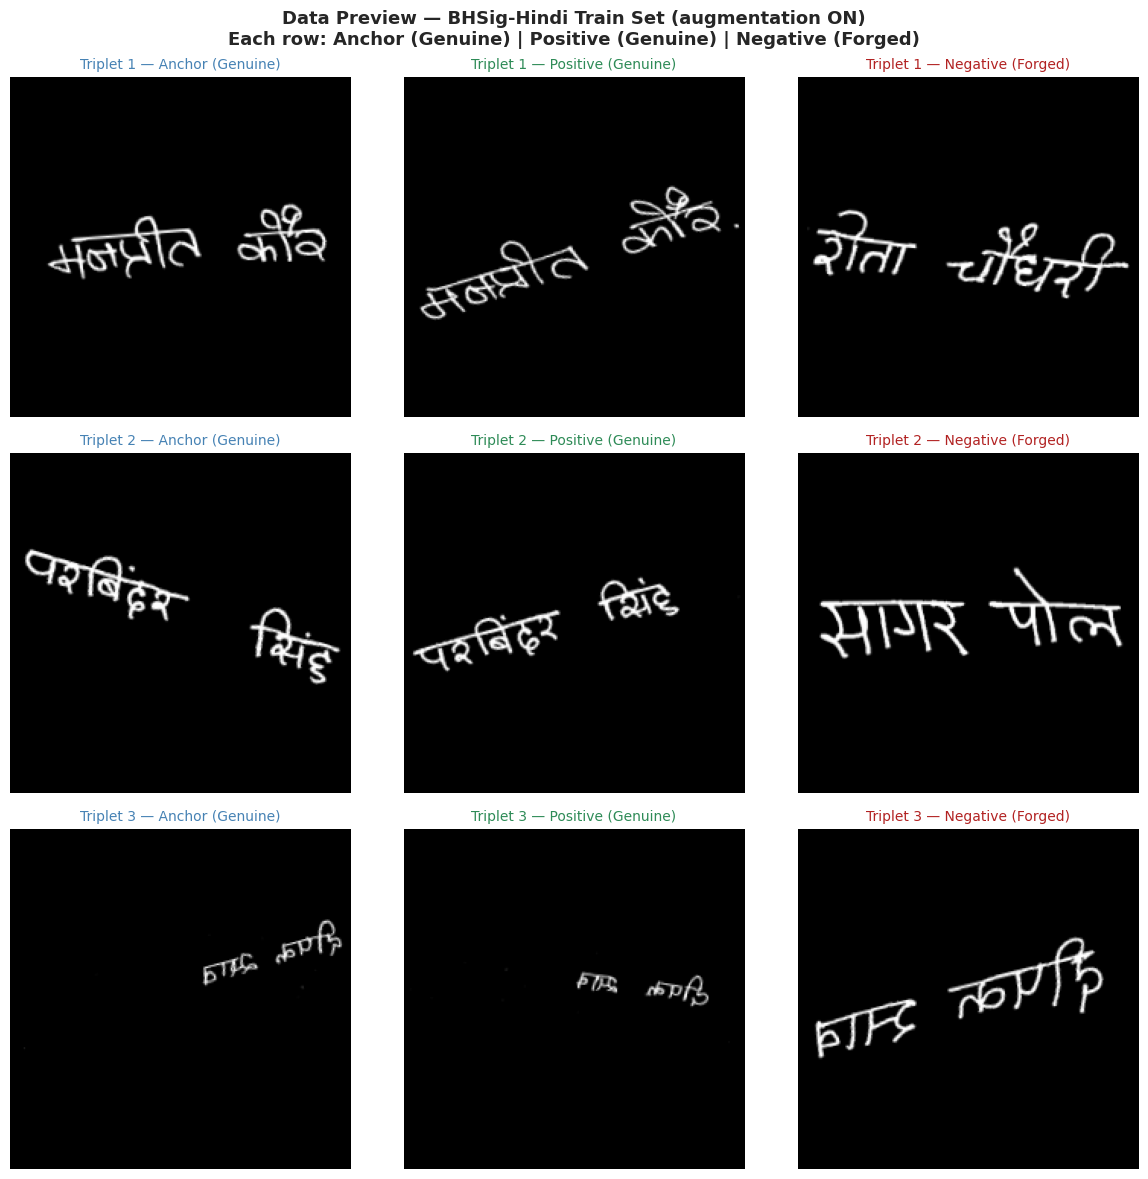

 > [Viz] Displayed 3 augmented triplets


In [5]:
def _unnorm(t):
    """Undo ImageNet normalisation for display. Returns H×W×C numpy in [0, 1]."""
    img  = t.cpu().numpy().transpose(1, 2, 0)          # C,H,W → H,W,C
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)

_prev_data = None
for _r in SPLIT_RATIOS:
    _f = os.path.join(SPLIT_DIR, f"{DATASET}_split_{_r}.json")
    if os.path.exists(_f):
        with open(_f) as _fh:
            _prev_data = json.load(_fh)
        print(f" > [Viz] Preview using split '{_r}'")
        break

if _prev_data is None:
    print(" > [Viz] No split file found — run prepare_split_ratios.py first")
else:
    _ds     = SplitTripletDataset(
        _prev_data['train'], input_shape=INPUT_SHAPE,
        val_transform=val_transform, training=True,
        hard_neg_ratio=HARD_NEG_RATIO
    )
    _loader = DataLoader(_ds, batch_size=4, shuffle=True, num_workers=0)
    _a, _p, _n, _ = next(iter(_loader))

    N = min(3, _a.size(0))
    fig, axes = plt.subplots(N, 3, figsize=(12, 4 * N))
    fig.suptitle(
        f"Data Preview — {DATASET_NAME} Train Set (augmentation ON)\n"
        "Each row: Anchor (Genuine) | Positive (Genuine) | Negative (Forged)",
        fontsize=13, fontweight='bold')

    if N == 1:
        axes = axes[np.newaxis, :]

    for i in range(N):
        for j, (tensor, title, color) in enumerate(zip(
                [_a[i], _p[i], _n[i]],
                ["Anchor (Genuine)", "Positive (Genuine)", "Negative (Forged)"],
                ['steelblue',        'seagreen',           'firebrick'])):
            axes[i, j].imshow(_unnorm(tensor))
            axes[i, j].set_title(f"Triplet {i+1} — {title}",
                                  fontsize=10, color=color)
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()
    print(f" > [Viz] Displayed {N} augmented triplets")

## Step 6 — Training Utilities

In [6]:
def freeze_backbone(fe):
    """
    Freeze all DenseNet-121 backbone parameters (Phase 1).
    Only CBAM modules and the projection head remain trainable.
    """
    for p in fe.get_backbone_params():
        p.requires_grad = False


def unfreeze_backbone(fe):
    """
    Unfreeze all model parameters for full fine-tuning (Phase 2).
    Called at epoch == phase1_epochs.
    """
    for p in fe.parameters():
        p.requires_grad = True


def validate(fe, loader, device):
    """
    Evaluate the feature extractor using pairwise distance on the unit hypersphere.

    For each (support, query) pair from SplitPairDataset:
        1. Compute L2-normalized embeddings for both images.
        2. Compute Squared Euclidean Distance (SED) ∈ [0, 4] on unit sphere.
        3. Convert to similarity score ∈ [0, 1]: score = 1 - SED / 4.
        4. Pass scores and labels to compute_metrics for EER, AUC, etc.

    Higher similarity score = more genuine. The EER threshold is the score
    value where FAR (false acceptance of forgeries) equals FRR (false
    rejection of genuines).

    return_curve_data=False is used here intentionally. validate() is called
    every VAL_EVERY epochs during training to monitor EER and save checkpoints.
    Curve data (fpr, tpr, thresholds arrays) is not needed for this purpose
    and would pollute best_metrics with numpy arrays that cannot be cleanly
    cast to float when saving the checkpoint.

    Args:
        fe     (DenseNetFeatureExtractor): Feature extractor in eval mode.
        loader (DataLoader)              : SplitPairDataset loader.
        device (torch.device)            : Target device.

    Returns:
        dict: Scalar metrics only — eer, auc, threshold, accuracy,
              precision, recall, f1.
    """
    fe.eval()
    all_scores, all_labels = [], []

    with torch.no_grad():
        for sup_imgs, qry_imgs, labels in loader:
            sup_imgs = sup_imgs.to(device, non_blocking=True)
            qry_imgs = qry_imgs.to(device, non_blocking=True)
            labels   = labels.to(device,   non_blocking=True)

            sup_feat = fe(sup_imgs)   # [B, 1024], L2-normalized
            qry_feat = fe(qry_imgs)   # [B, 1024], L2-normalized

            # SED on unit sphere: ||z_s - z_q||² ∈ [0, 4]
            distances = torch.sum((sup_feat - qry_feat) ** 2, dim=1)

            # Similarity score: higher = more genuine
            scores = 1.0 - (distances / 4.0)   # ∈ [0, 1]

            all_scores.extend(scores.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    # return_curve_data=False — scalar metrics only, no numpy arrays.
    # This keeps best_metrics clean for checkpoint saving.
    return compute_metrics(all_labels, all_scores, return_curve_data=False)


def evaluate_model(fe, loader, device, output_dir=None, silent=False):
    """
    Run full evaluation with curve data and optionally save plots.

    Unlike validate(), this calls compute_metrics with return_curve_data=True
    so that ROC, DET, FAR/FRR, and score distribution plots can be generated.
    This is called only once at the end of training for final test evaluation.

    Args:
        fe         (DenseNetFeatureExtractor): Feature extractor.
        loader     (DataLoader)              : SplitPairDataset test loader.
        device     (torch.device)            : Target device.
        output_dir (str, optional)           : Directory to save evaluation plots.
        silent     (bool)                    : If True, suppresses print output.

    Returns:
        dict: Full metrics dictionary including curve data for plots.
    """
    fe.eval()
    all_scores, all_labels = [], []

    with torch.no_grad():
        for sup_imgs, qry_imgs, labels in loader:
            sup_imgs = sup_imgs.to(device, non_blocking=True)
            qry_imgs = qry_imgs.to(device, non_blocking=True)

            sup_feat  = fe(sup_imgs)
            qry_feat  = fe(qry_imgs)
            distances = torch.sum((sup_feat - qry_feat) ** 2, dim=1)
            scores    = 1.0 - (distances / 4.0)

            all_scores.extend(scores.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    # return_curve_data=True — needed for plot generation
    metrics = compute_metrics(all_labels, all_scores, return_curve_data=True)

    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        for k, fmt in [('eer',       ':.2%'),
                       ('auc',       ':.4f'),
                       ('threshold', ':.4f'),
                       ('accuracy',  ':.2%'),
                       ('precision', ':.2%'),
                       ('recall',    ':.2%'),
                       ('f1',        ':.2%')]:
            print(f"  {k.upper():<13}: {metrics.get(k, 0):{fmt[1:]}}")
        print("=" * 38)
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)

    return metrics


def run_training(train_user_dict, val_user_dict, test_user_dict,
                 device, checkpoint_path,
                 epochs, phase1_epochs, lr,
                 margin, weight_decay, batch_size,
                 zero_active_patience=5,
                 output_dir=None):
    """
    Complete two-phase triplet training loop with offline hard negative mining.

    Phase 1 — Head warm-up (epochs 1 → phase1_epochs):
        DenseNet-121 backbone is frozen. Only CBAM modules and the
        projection head are trained. This prevents the randomly initialized
        head from corrupting pretrained ImageNet features with noisy gradients.
        Optimizer : AdamW on head params only, LR = lr.
        Scheduler : None (LR reduction is not meaningful before backbone unfreezes).

    Phase 2 — Full fine-tuning (epochs phase1_epochs+1 → epochs):
        All parameters unfrozen. Differential learning rates applied:
            Backbone : lr × 0.1  (conservative — preserves pretrained features)
            Head     : lr        (continued head adaptation)
        Scheduler : ReduceLROnPlateau on validation EER, patience=3, factor=0.5.

    Validation protocol:
        Runs every VAL_EVERY=3 epochs and always on the final epoch.
        Uses exhaustive pairwise SplitPairDataset evaluation on validation writers.
        Checkpoint saved on minimum validation EER (not minimum loss).
        validate() returns scalar metrics only (return_curve_data=False) to
        ensure the checkpoint metrics dict contains only plain Python floats.

    Triplet regeneration:
        _generate_triplets() is called at the end of each epoch to produce a
        fresh set of (anchor, positive, negative) triplets, preventing the
        model from memorising fixed pairings across epochs.

    Checkpoint format:
        {
            'feature_extractor': state_dict,
            'metrics': {
                'eer':       float,
                'auc':       float,
                'threshold': float,   ← EER threshold, read by app.py
                'accuracy':  float,
                'precision': float,
                'recall':    float,
                'f1':        float,
            }
        }

    Args:
        train_user_dict      (dict)        : {uid: {'genuine': [...], 'forged': [...]}}
        val_user_dict        (dict)        : Same structure — validation writers.
        test_user_dict       (dict)        : Same structure — test writers.
        device               (torch.device): Target device.
        checkpoint_path      (str)         : Path to save best model checkpoint.
        epochs               (int)         : Maximum training epochs (safety ceiling).
        phase1_epochs        (int)         : Epochs to keep backbone frozen.
        lr                   (float)       : Base learning rate.
        margin               (float)       : Triplet loss margin (SED, unit sphere).
        weight_decay         (float)       : AdamW weight decay.
        batch_size           (int)         : Training batch size.
        zero_active_patience (int)         : Consecutive Phase 2 val checks with
                                             active fraction < 1% before early stop.
                                             Default 5 (~15 epochs). Set to 0 to
                                             disable early stopping entirely.
        output_dir           (str)         : Directory for final test evaluation plots.

    Returns:
        dict: Final test metrics (eer, auc, threshold, accuracy, precision,
              recall, f1, plus curve data for plot generation).
    """
    VAL_EVERY = 3

    print(f"\n   {'─'*60}")
    print(f"   TRIPLET TRAINING  |  {epochs} epochs max  "
          f"(P1 frozen: {phase1_epochs})")
    print(f"   LR: {lr}  |  Margin: {margin}  |  "
          f"WD: {weight_decay}  |  Batch: {batch_size}")
    if zero_active_patience > 0:
        print(f"   Early stop: active < 1% for {zero_active_patience} "
              f"consecutive val checks (~{zero_active_patience * VAL_EVERY} epochs) "
              f"[Phase 2 only]")
    else:
        print(f"   Early stop: DISABLED (zero_active_patience=0)")
    print(f"   {'─'*60}")

    seed_everything(42)
    t0 = time.time()

    # ── Datasets ──────────────────────────────────────────────────────────────
    train_dataset = SplitTripletDataset(
        train_user_dict, input_shape=INPUT_SHAPE,
        val_transform=val_transform, training=True,
        hard_neg_ratio=HARD_NEG_RATIO
    )
    val_dataset = SplitPairDataset(
        val_user_dict, input_shape=INPUT_SHAPE, transform=val_transform
    )
    test_dataset = SplitPairDataset(
        test_user_dict, input_shape=INPUT_SHAPE, transform=val_transform
    )

    # ── DataLoaders ───────────────────────────────────────────────────────────
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
        persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0)
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0)
    )

    # ── Model + Loss + AMP ────────────────────────────────────────────────────
    model     = tDCBAM(backbone_name='densenet121',
                       output_dim=FEATURE_DIM, pretrained=True).to(device)
    criterion = TripletLoss(margin=margin, mode='euclidean')
    scaler    = torch.amp.GradScaler('cuda')

    # ── Phase 1 Setup ─────────────────────────────────────────────────────────
    freeze_backbone(model.feature_extractor)
    optimizer = optim.AdamW(model.get_head_params(), lr=lr, weight_decay=weight_decay)
    scheduler = None
    best_eer  = float('inf')
    best_metrics = {}
    zero_active_counter = 0

    history = {
        'train_loss': [],
        'val_epochs': [],
        'val_eer':    []
    }

    # ── Training Loop ─────────────────────────────────────────────────────────
    for epoch in range(epochs):

        # ── Phase transition ──────────────────────────────────────────────────
        if epoch == phase1_epochs:
            unfreeze_backbone(model.feature_extractor)
            optimizer = optim.AdamW([
                {'params': model.get_backbone_params(), 'lr': TRAIN_LR * BACKBONE_LR_RATIO},
                {'params': model.get_head_params(),     'lr': TRAIN_LR}
            ], weight_decay=TRAIN_WEIGHT_DECAY)

            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=SCHEDULER_PATIENCE, min_lr=1e-6
            )

        model.train()
        epoch_loss = 0.0

        for anchor, pos, neg, _ in tqdm(
                train_loader, desc=f"Train E{epoch+1:02d}", leave=False):

            anchor, pos, neg = anchor.to(device, non_blocking=True), pos.to(device, non_blocking=True), neg.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                loss = criterion(*model(anchor, pos, neg))

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        phase    = 1 if epoch < phase1_epochs else 2
        
        history['train_loss'].append(avg_loss)

        # ── Periodic validation ───────────────────────────────────────────────
        should_validate = ((epoch + 1) % VAL_EVERY == 0 or (epoch + 1) == epochs)

        if should_validate:
            val_metrics = validate(model.feature_extractor, val_loader, device)
            val_eer = val_metrics['eer']

            history['val_epochs'].append(epoch + 1)
            history['val_eer'].append(val_eer)

            print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Active: {criterion.last_fraction_active:.1%} | "
                  f"Val EER: {val_eer:.2%}")

            if scheduler is not None:
                scheduler.step(val_eer)

            if zero_active_patience > 0 and epoch >= phase1_epochs:
                if criterion.last_fraction_active < 0.01:
                    zero_active_counter += 1
                    if zero_active_counter >= zero_active_patience:
                        print(f"   >>> Early stopping — active triplets < 1% for {zero_active_patience} checks")
                        train_dataset._generate_triplets()
                        break
                else:
                    zero_active_counter = 0

            if val_eer < best_eer:
                best_eer, best_metrics = val_eer, val_metrics
                torch.save({'feature_extractor': model.feature_extractor.state_dict(), 'metrics': {k: float(v) for k, v in best_metrics.items()}}, checkpoint_path)
                print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%} | Threshold: {val_metrics['threshold']:.4f})")
        else:
            print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.4f} | (skipping val)")

        train_dataset._generate_triplets()

    if output_dir:
        n_epochs_run = len(history['train_loss'])
        epoch_axis   = list(range(1, n_epochs_run + 1))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Proposed tDCBAM — {DATASET_NAME}\nTraining Loss & Validation EER', fontsize=13, fontweight='bold')

        ax1.plot(epoch_axis, history['train_loss'], label='Train Triplet Loss', color='steelblue', linewidth=2)
        if n_epochs_run > phase1_epochs:
            ax1.axvline(x=phase1_epochs, color='gray', linestyle='--', alpha=0.7, label='Backbone Unfrozen')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Triplet Margin Loss'); ax1.set_title('Training Loss')
        ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5)

        if history['val_epochs']:
            ax2.plot(history['val_epochs'], history['val_eer'], label='Val EER', color='darkorchid', linewidth=2, marker='o')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('EER'); ax2.set_title('Validation EER')
        ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        loss_plot_path = os.path.join(output_dir, 'loss_curve.png')
        plt.savefig(loss_plot_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"   >>> Loss/EER curve saved → {loss_plot_path}")

    # ── Final test evaluation ─────────────────────────────────────────────────
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.feature_extractor.load_state_dict(ckpt['feature_extractor'], strict=True)
        print("   Best checkpoint reloaded for final test evaluation")

    final_metrics = evaluate_model(model.feature_extractor, test_loader, device, output_dir=output_dir, silent=False)
    print(f"\n   Training done | Best Val EER: {best_eer:.2%} | Time: {time.time() - t0:.1f}s")

    return final_metrics

print(" > [Utils] All training functions defined")

 > [Utils] All training functions defined


## Step 7 — Run All Splits

In [7]:
all_results = {}
timing_log  = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    tr_p, va_p, te_p = ratio.split('_')
    split_label    = f"{tr_p}:{va_p}:{te_p}"
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{tr_p}-{va_p}-{te_p}")
    exp_dir        = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")

    os.makedirs(split_eval_dir, exist_ok=True)
    os.makedirs(exp_dir,        exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  {DATASET_NAME}  —  {split_label}  Split")
    print(f"{'='*70}")
    print(f" > [Config] Dataset: {DATASET_NAME} | Split: {split_label}")
    print(f" > [Config] Triplet Training: {TRAIN_EPOCHS} ep "
          f"(P1 frozen: {TRAIN_PHASE1_EPOCHS}) | margin={TRAIN_MARGIN}")
    print(f" > [Config] LR: {TRAIN_LR} | WD: {TRAIN_WEIGHT_DECAY} | "
          f"Checkpoints: {CHECKPOINT_DIR}")

    if not os.path.exists(split_file):
        print(f"  SKIPPED: split file not found ({split_file})")
        continue

    with open(split_file) as f:
        split_data = json.load(f)

    train_dict = split_data['train']
    val_dict   = split_data['val']
    test_dict  = split_data['test']
    print(f"  Writers — Train: {len(train_dict)} | "
          f"Val: {len(val_dict)} | Test: {len(test_dict)}")

    # ── Triplet Training ──────────────────────────────────────────────────────
    seed_everything(42)
    checkpoint_path = os.path.join(exp_dir, "best_triplet_model.pth")
    t0_train = time.time()

    best_metrics = run_training(
        train_user_dict=train_dict,
        val_user_dict=val_dict,
        test_user_dict=test_dict,
        device=DEVICE,
        checkpoint_path=checkpoint_path,
        epochs=TRAIN_EPOCHS,
        phase1_epochs=TRAIN_PHASE1_EPOCHS,
        lr=TRAIN_LR,
        margin=TRAIN_MARGIN,
        weight_decay=TRAIN_WEIGHT_DECAY,
        batch_size=TRAIN_BATCH_SIZE,
        zero_active_patience=ZERO_ACTIVE_PATIENCE,
        output_dir=split_eval_dir
    )
    t_train = time.time() - t0_train

    # ── Record results ────────────────────────────────────────────────────────
    key = f"{DATASET_NAME} ({split_label})"
    all_results[key] = {
        'dataset':     DATASET_NAME,
        'split':       split_label,
        'train_users': len(train_dict),
        'val_users':   len(val_dict),
        'test_users':  len(test_dict),
        'eer':         float(best_metrics['eer']),
        'accuracy':    float(best_metrics['accuracy']),
        'auc':         float(best_metrics['auc']),
        'precision':   float(best_metrics.get('precision', 0)),
        'recall':      float(best_metrics.get('recall',    0)),
        'f1':          float(best_metrics.get('f1',        0)),
    }
    timing_log[key] = {
        'train_s': round(t_train, 1),
        'total_s': round(t_train, 1)
    }

    print(f"  RESULT [{split_label}]: "
          f"EER={best_metrics['eer']:.2%} | "
          f"Acc={best_metrics['accuracy']:.2%} | "
          f"AUC={best_metrics['auc']:.4f} | "
          f"F1={best_metrics.get('f1', 0):.4f} | "
          f"Time={t_train:.1f}s")

print(f"\n{'='*70}\nALL EXPERIMENTS COMPLETE\n{'='*70}")


  BHSig-Hindi  —  70:15:15  Split
 > [Config] Dataset: BHSig-Hindi | Split: 70:15:15
 > [Config] Triplet Training: 100 ep (P1 frozen: 13) | margin=0.5538629628394433
 > [Config] LR: 0.0003631126919850215 | WD: 0.0008250424348545071 | Checkpoints: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits
  Writers — Train: 112 | Val: 24 | Test: 24
 > [Seed] 42

   ────────────────────────────────────────────────────────────
   TRIPLET TRAINING  |  100 epochs max  (P1 frozen: 13)
   LR: 0.0003631126919850215  |  Margin: 0.5538629628394433  |  WD: 0.0008250424348545071  |  Batch: 32
   Early stop: active < 1% for 5 consecutive val checks (~15 epochs) [Phase 2 only]
   ────────────────────────────────────────────────────────────
 > [Seed] 42
   TripletDataset: 2688 triplets | 112 users | triplet-level aug
   PairDataset: 23904 pairs (6624 genuine, 17280 forged)
   PairDataset: 23904 pairs (6624 genuine, 17280 forged)


Train E01:   0%|          | 0/84 [00:00<?, ?it/s]

   [P1] Epoch 01/100 | Loss: 0.4256 | (skipping val)


Train E02:   0%|          | 0/84 [00:00<?, ?it/s]

   [P1] Epoch 02/100 | Loss: 0.3959 | (skipping val)


...

   [P2] Epoch 98/100 | Loss: 0.0149 | (skipping val)


Train E99:   0%|          | 0/72 [00:00<?, ?it/s]

   [P2] Epoch 99/100 | Loss: 0.0446 | Active: 3.1% | Val EER: 18.55%


Train E100:   0%|          | 0/72 [00:00<?, ?it/s]

   [P2] Epoch 100/100 | Loss: 0.0331 | Active: 0.0% | Val EER: 17.77%
   >>> Loss/EER curve saved → /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bhsig_hindi/tDCBAM_bhsig_hindi_60-20-20/loss_curve.png
   Best checkpoint reloaded for final test evaluation

========== FINAL TEST RESULTS ==========
  EER          : 16.01%
  AUC          : 0.9140
  THRESHOLD    : 0.7780
  ACCURACY     : 83.98%
  PRECISION    : 66.78%
  RECALL       : 83.97%
  F1           : 74.39%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bhsig_hindi/tDCBAM_bhsig_hindi_60-20-20/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bhsig_hindi/tDCBAM_bhsig_hindi_60-20-20/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bhsig_hindi/tDCBAM_bhsig_hindi_60-20-20/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bhsig_h

## Step 8 — Summary Table

In [8]:
W = 84
print(f"\n{'='*W}")
print(f"{'PROPOSED MODEL  —  ' + DATASET_NAME:^{W}}")
print(f"{'DenseNet-121 + CBAM + Triplet Loss':^{W}}")
print(f"{'='*W}")
print(f"{'Split':<12} {'Train':>6} {'Val':>6} {'Test':>6}  "
      f"{'EER':>8} {'Accuracy':>9} {'AUC':>8} {'F1':>8}  "
      f"{'Time(s)':>8}")
print(f"{'-'*W}")
for key, res in all_results.items():
    t = timing_log.get(key, {})
    print(f"{res['split']:<12} {res['train_users']:>6} {res['val_users']:>6} "
          f"{res['test_users']:>6}  {res['eer']:>8.4f} {res['accuracy']:>9.4f} "
          f"{res['auc']:>8.4f} {res['f1']:>8.4f}  "
          f"{str(t.get('total_s', '—')):>8}")
print(f"{'='*W}")

results_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump({'results': all_results, 'timing': timing_log}, f, indent=2)
print(f"\n > Results saved → {results_path}")




                           PROPOSED MODEL  —  BHSig-Hindi                           
                         DenseNet-121 + CBAM + Triplet Loss                         
Split         Train    Val   Test       EER  Accuracy      AUC       F1   Time(s)
------------------------------------------------------------------------------------
70:15:15        112     24     24    0.1369    0.8631   0.9363   0.7775    1879.6
65:18:18        104     28     28    0.1208    0.8792   0.9481   0.8013    2620.4
60:20:20         96     32     32    0.1601    0.8398   0.9140   0.7439    2725.2

 > Results saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_bhsig_hindi_results.json


## Step 9 — Embedding Space Visualization (t-SNE)


  Step 10 — t-SNE Visualization (Best Model Auto-Selection)
  Dataset : BHSig-Hindi
  Selected: 65:18:18 split (Achieved lowest EER: 12.08%)

 > Reloading test data for 65:18:18 split...
   PairDataset: 27888 pairs (7728 genuine, 20160 forged)
 > Loading best feature extractor from checkpoint...
 > Checkpoint loaded | Val EER: 13.97% | Threshold: 0.7725
 > Extracting embeddings for t-SNE...
 > Collected 960 embeddings (253 genuine, 707 forged)
 > Running t-SNE on 960 × 1024D embeddings...
 > t-SNE plot saved → /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_bhsig_hindi/tDCBAM_bhsig_hindi_65-18-18/tsne_bhsig_hindi.png


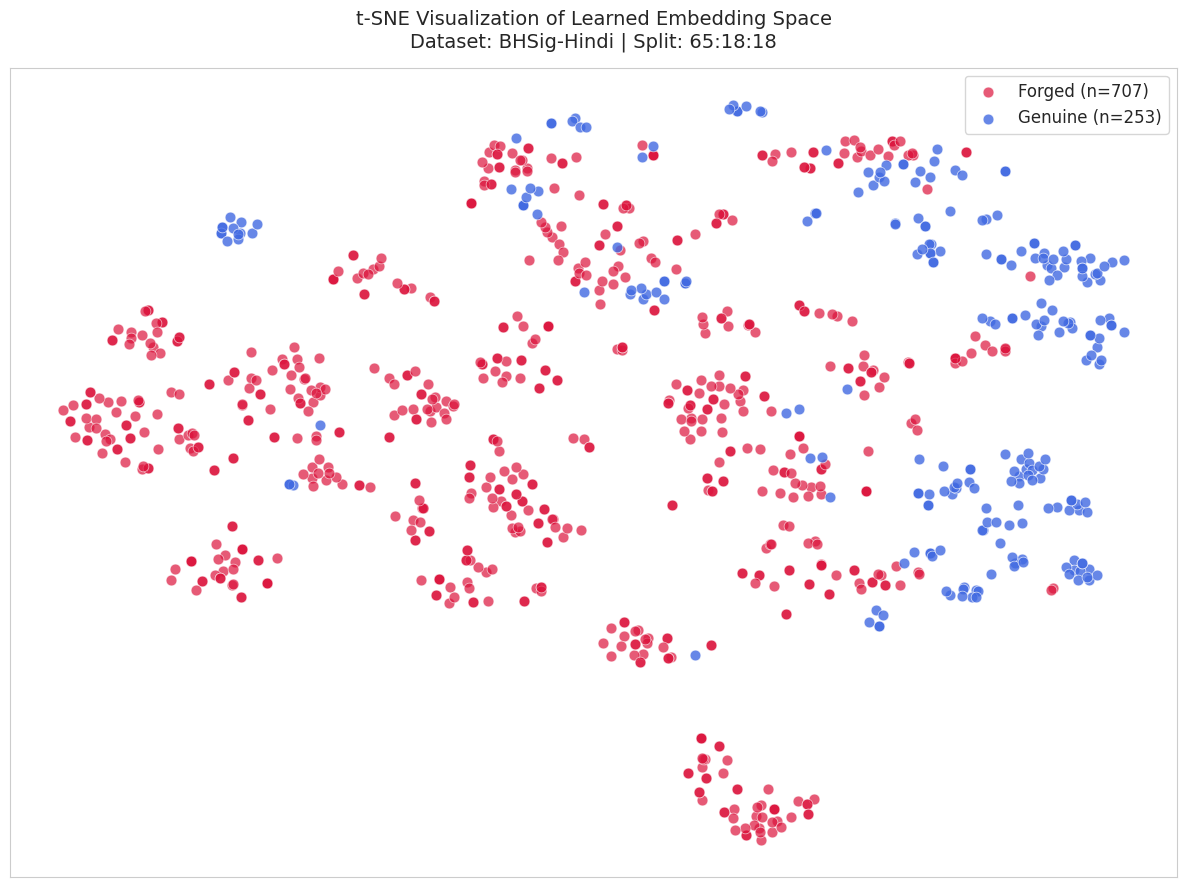

In [9]:
def visualize_embedding_space(feature_extractor, dataloader, device,
                               num_batches=15, output_dir=None,
                               dataset_name='', split_label=''):
    """
    Extracts L2-normalized 1024D embeddings from the feature extractor
    and compresses them to 2D using t-SNE to visualize genuine/forged
    cluster separation in the learned metric space.

    Args:
        feature_extractor (DenseNetFeatureExtractor): Trained extractor.
        dataloader        (DataLoader)              : SplitPairDataset loader.
        device            (torch.device)            : Target device.
        num_batches       (int)                     : Batches to sample.
        output_dir        (str)                     : Directory to save plot.
        dataset_name      (str)                     : For plot title.
        split_label       (str)                     : For plot title.
    """
    feature_extractor.eval()
    all_embeddings = []
    all_labels     = []

    print(" > Extracting embeddings for t-SNE...")

    with torch.no_grad():
        for i, (sup_imgs, qry_imgs, labels) in enumerate(dataloader):
            if i >= num_batches:
                break

            qry_imgs = qry_imgs.to(device, non_blocking=True)

            # Extract L2-normalized 1024D embeddings
            # feature_extractor applies normalize=True internally
            features = feature_extractor(qry_imgs).cpu().numpy()

            all_embeddings.append(features)
            all_labels.append(labels.cpu().numpy())

    embeddings_np = np.vstack(all_embeddings)
    labels_np     = np.concatenate(all_labels)

    n_genuine = int((labels_np == 1).sum())
    n_forged  = int((labels_np == 0).sum())
    print(f" > Collected {embeddings_np.shape[0]} embeddings "
          f"({n_genuine} genuine, {n_forged} forged)")
    print(f" > Running t-SNE on {embeddings_np.shape[0]} × "
          f"{embeddings_np.shape[1]}D embeddings...")

    # Compress 1024D → 2D
    # init='pca' gives more stable and reproducible results than random init.
    # perplexity=30 works well for datasets of this size (~500-1000 points).
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        init='pca',
        learning_rate='auto'
    )
    embeddings_2d = tsne.fit_transform(embeddings_np)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 9))

    # Plot forgeries first so they sit behind genuine points if overlapping
    ax.scatter(
        embeddings_2d[labels_np == 0, 0],
        embeddings_2d[labels_np == 0, 1],
        c='crimson', label=f'Forged (n={n_forged})',
        alpha=0.7, edgecolors='white', s=60, linewidth=0.5
    )
    ax.scatter(
        embeddings_2d[labels_np == 1, 0],
        embeddings_2d[labels_np == 1, 1],
        c='royalblue', label=f'Genuine (n={n_genuine})',
        alpha=0.8, edgecolors='white', s=60, linewidth=0.5
    )

    ax.set_title(
        f't-SNE Visualization of Learned Embedding Space\n'
        f'Dataset: {dataset_name} | Split: {split_label}',
        fontsize=14, pad=15
    )
    ax.legend(fontsize=12, loc='best')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()

    if output_dir:
        tsne_plot_path = os.path.join(
            output_dir, f'tsne_{dataset_name.lower().replace("-", "_")}.png'
        )
        plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight')
        print(f" > t-SNE plot saved → {tsne_plot_path}")

    plt.show()
    plt.close(fig)

if not all_results:
    raise ValueError("No results found. Did the training loop run successfully?")

best_split_key   = min(all_results, key=lambda k: all_results[k]['eer'])
best_split_info  = all_results[best_split_key]
best_split_label = best_split_info['split']
best_ratio       = best_split_label.replace(':', '_')
best_eer_val     = best_split_info['eer']

print(f"\n{'='*70}")
print(f"  Step 10 — t-SNE Visualization (Best Model Auto-Selection)")
print(f"  Dataset : {DATASET_NAME}")
print(f"  Selected: {best_split_label} split (Achieved lowest EER: {best_eer_val:.2%})")
print(f"{'='*70}\n")

best_exp_dir        = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{best_ratio}")
# Convert 70_15_15 back to 70-15-15 for the eval dir matching your loop logic
best_split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{best_ratio.replace('_', '-')}")
best_split_file     = os.path.join(SPLIT_DIR, f"{DATASET}_split_{best_ratio}.json")

print(f" > Reloading test data for {best_split_label} split...")
with open(best_split_file) as f:
    best_split_data = json.load(f)
best_test_dict = best_split_data['test']

tsne_test_set = SplitPairDataset(
    best_test_dict,
    input_shape=INPUT_SHAPE,
    transform=val_transform
)

# num_workers=0 — safe in Jupyter (avoids forkserver issues)
tsne_test_loader = DataLoader(
    tsne_test_set, batch_size=64, shuffle=True,
    num_workers=0, pin_memory=True
)

print(" > Loading best feature extractor from checkpoint...")

tsne_model = tDCBAM(
    backbone_name='densenet121',
    output_dim=FEATURE_DIM,
    pretrained=False
).to(DEVICE)

best_ckpt_path = os.path.join(best_exp_dir, "best_triplet_model.pth")

if not os.path.exists(best_ckpt_path):
    print(f" > ERROR: Checkpoint not found at {best_ckpt_path}")
else:
    # weights_only=False required — checkpoint contains plain Python floats
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)

    # Checkpoint format: {'feature_extractor': state_dict, 'metrics': {...}}
    if isinstance(ckpt, dict) and 'feature_extractor' in ckpt:
        tsne_model.feature_extractor.load_state_dict(
            ckpt['feature_extractor'], strict=True
        )
        threshold = ckpt.get('metrics', {}).get('threshold', 'N/A')
        print(f" > Checkpoint loaded | "
              f"Val EER: {ckpt['metrics'].get('eer', 0):.2%} | "
              f"Threshold: {threshold:.4f}" if isinstance(threshold, float)
              else f" > Checkpoint loaded (legacy format)")
    else:
        # Legacy bare state dict format
        tsne_model.feature_extractor.load_state_dict(ckpt, strict=True)
        print(" > Checkpoint loaded (legacy bare state dict format)")

    visualize_embedding_space(
        feature_extractor=tsne_model.feature_extractor,
        dataloader=tsne_test_loader,
        device=DEVICE,
        num_batches=15,
        output_dir=best_split_eval_dir,
        dataset_name=DATASET_NAME,
        split_label=best_split_label
    )

## Step 10 — Results Chart

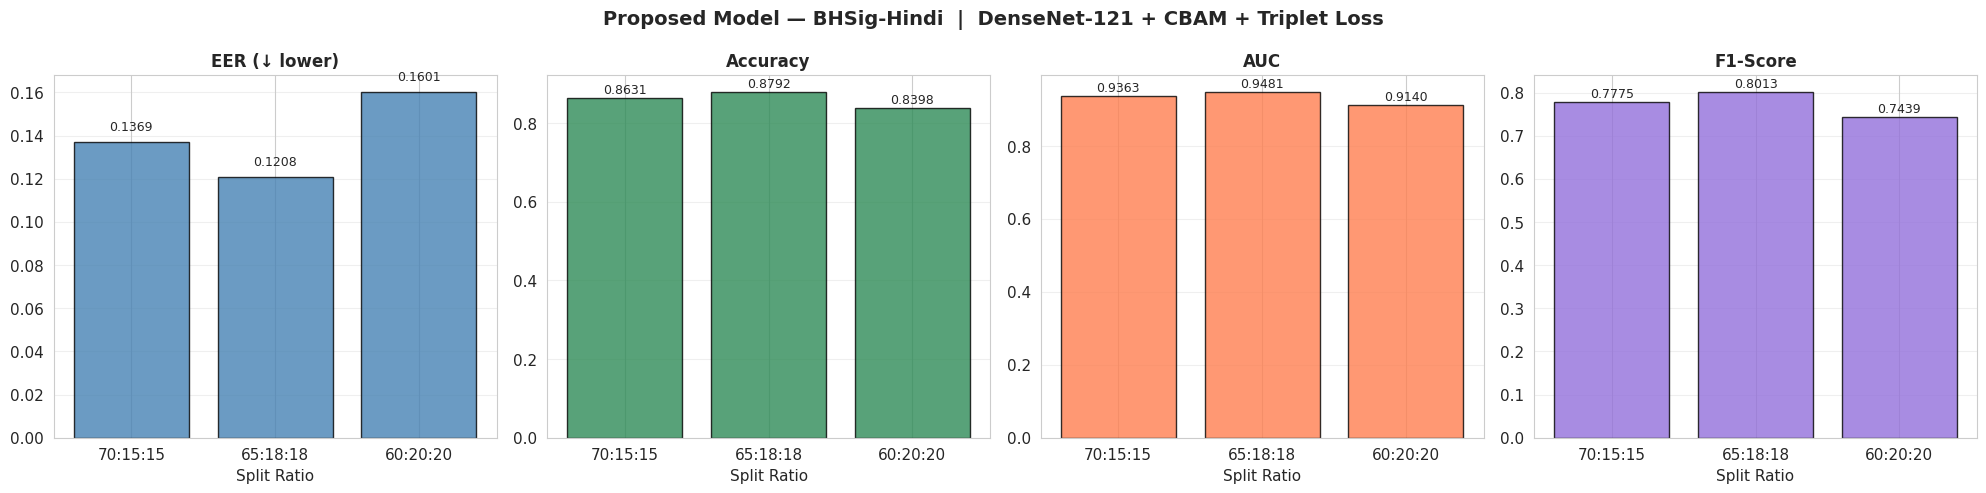

 > Plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_bhsig_hindi_comparison.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    f'Proposed Model — {DATASET_NAME}  |  DenseNet-121 + CBAM + Triplet Loss',
    fontsize=14, fontweight='bold'
)

for ax, metric, title, color in zip(
        axes,
        ['eer',           'accuracy',  'auc',   'f1'],
        ['EER (↓ lower)', 'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',     'seagreen',  'coral', 'mediumpurple']):

    split_labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [
        all_results.get(f"{DATASET_NAME} ({r.replace('_', ':')})", {}).get(metric, 0)
        for r in SPLIT_RATIOS
    ]

    bars = ax.bar(split_labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")